In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd

In [3]:
df=pd.read_csv("mnist_dataset.csv")

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Train Images :", x_train.shape)
print("Train Labels :", y_train.shape)
print("Test Images :", x_test.shape)
print("Test Labels :", y_test.shape)

Train Images : (60000, 28, 28)
Train Labels : (60000,)
Test Images : (10000, 28, 28)
Test Labels : (10000,)


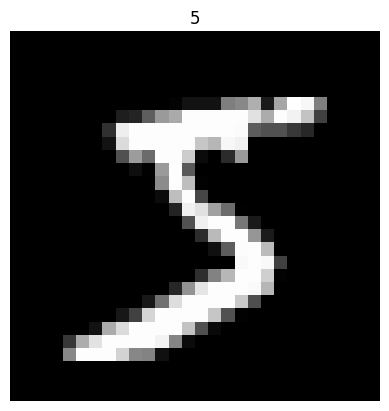

In [4]:
plt.imshow(x_train[0], cmap="gray")
plt.title(y_train[0])
plt.axis("off")
plt.show()

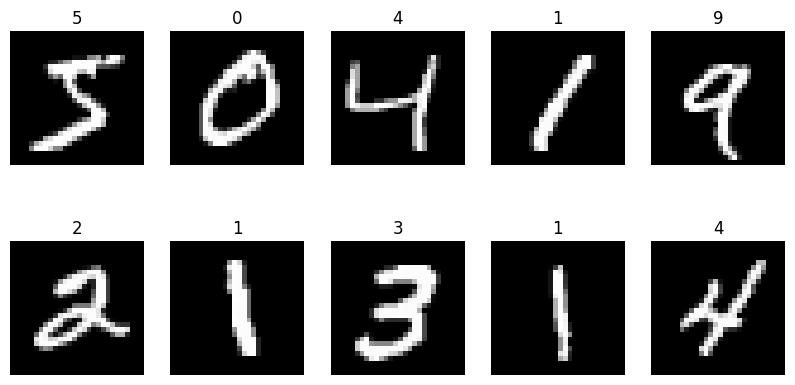

In [5]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")

plt.show()

In [6]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [7]:
x_train = x_train.reshape(-1,784)
x_test = x_test.reshape(-1,784)

print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


In [8]:
y_train = keras.utils.to_categorical(y_train,10)
y_test = keras.utils.to_categorical(y_test,10)

In [9]:
model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

c:\Users\sandhya\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 47ms/step - accuracy: 0.9306 - loss: 0.2349 - val_accuracy: 0.9615 - val_loss: 0.1273
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 75s 42ms/step - accuracy: 0.9693 - loss: 0.0982 - val_accuracy: 0.9644 - val_loss: 0.1155
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 58s 39ms/step - accuracy: 0.9792 - loss: 0.0691 - val_accuracy: 0.9693 - val_loss: 0.1055
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 89s 43ms/step - accuracy: 0.9830 - loss: 0.0533 - val_accuracy: 0.9701 - val_loss: 0.1094
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 68s 33ms/step - accuracy: 0.9867 - loss: 0.0422 - val_accuracy: 0.9758 - val_loss: 0.0917


In [12]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Loss :", loss)
print("Accuracy :", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9770 - loss: 0.0833
Loss : 0.08325386792421341
Accuracy : 0.9769999980926514


In [13]:
prediction = model.predict(x_test)

index = 0

true = np.argmax(y_test[index])
pred = np.argmax(prediction[index])

print("True :", true)
print("Predicted :", pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
True : 7
Predicted : 7


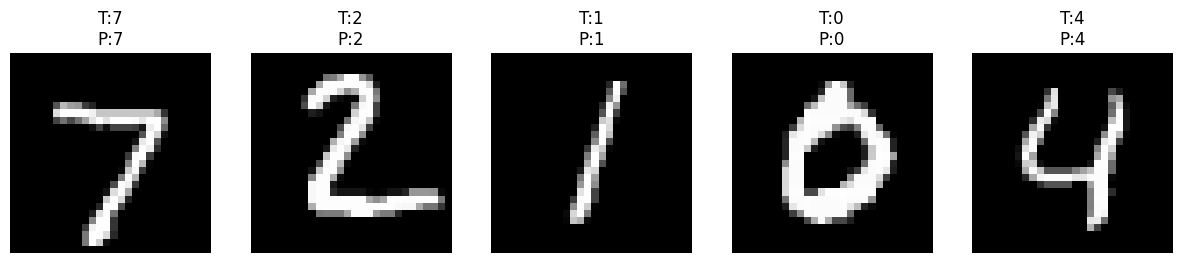

In [14]:
prediction = model.predict(x_test, verbose=0)

plt.figure(figsize=(15,3))

for i in range(5):

    true = np.argmax(y_test[i])
    pred = np.argmax(prediction[i])

    plt.subplot(1,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.title(f"T:{true}\nP:{pred}")
    plt.axis("off")

plt.show()

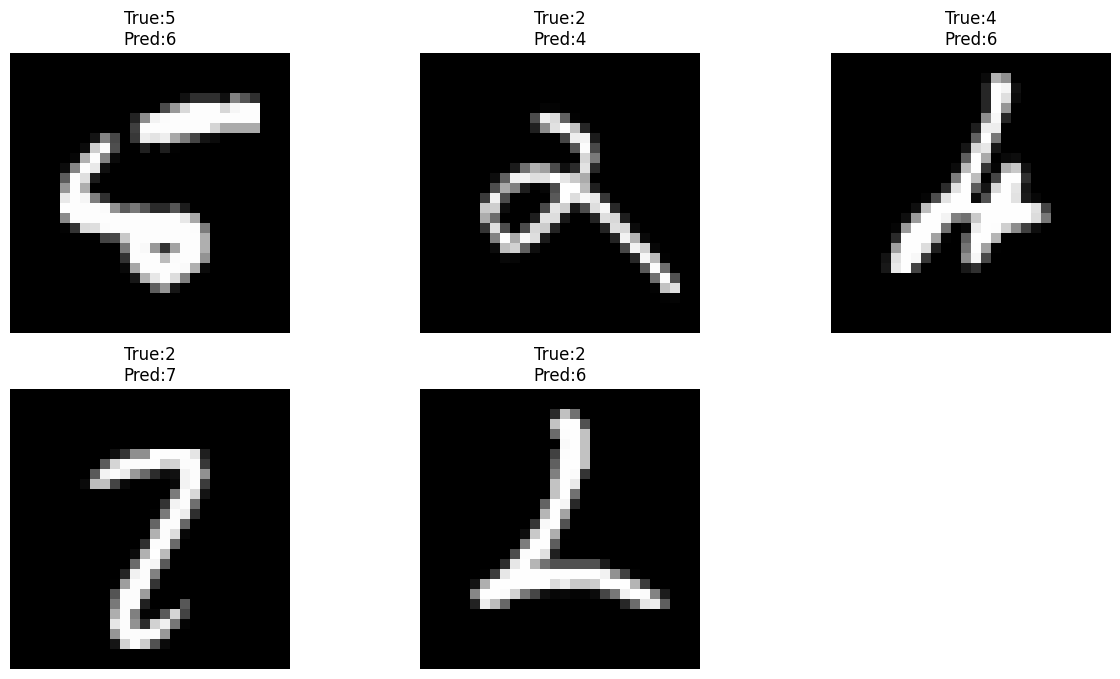

In [15]:
prediction = model.predict(x_test, verbose=0)

plt.figure(figsize=(15,8))

count = 0

for i in range(len(x_test)):

    true = np.argmax(y_test[i])
    pred = np.argmax(prediction[i])

    if true != pred:

        count += 1

        plt.subplot(2,3,count)
        plt.imshow(x_test[i].reshape(28,28), cmap="gray")
        plt.title(f"True:{true}\nPred:{pred}")
        plt.axis("off")

        if count == 5:
            break

plt.show()